Curator: Louise Marie Maganto

Reviewer: HERE (Your team member's name)

Title: SDE model of SARS disease in Hong Kong and Singapore with parameter stochasticity

Pathogen: SARS

DOI: https://doi.org/10.1063/1.5064215

Figure: 4 SARS Singapore

Outcome: Sucessful 

Notes:  Since diffusion and draft function uses p as variable and the research paper uses p I will be renaming p in the research paper as p1. Also for mu1 and mu2 we are given a list of values to choose from I choose one value from the list at random. 

In [ ]:
variable_names = [
    'S',
    'I'
]
"""Names of the variables in the SDE model. The order of the variables should be the same as the order of the drift and diffusion terms returned by the drift_term and diffusion_term functions."""

parameter_names = [
    'beta',
    'gamma0',
    'gamma1',
    'mu', 
    'mu1',
    'mu2',
    'p1',
    'sigma1',
    'sigma2'
    
]
"""Names of the parameters in the SDE model. The order of the parameters should be the same as the order of the values returned by the drift_term and diffusion_term functions."""

initial_values = dict(
    S = 4114980.0, #N = 4115000, N = S + I
    I = 20.0
)
"""Dictionary of initial values for the variables in the SDE model. The keys should be the variable names in variable_names and the values should be the initial values for those variables."""

parameter_values = dict(
    beta = 0.109,
    gamma0 = 0.213,
    gamma1 = 1/14,
    mu = 1/(79 * 365),
    mu1 = 0.3,  #Source: page 4 there are multiple mu1 to choose from mu1 = 0,0.3,0.6,0.9
    mu2 = 0,
    p1 = 0.3,
    sigma1 = 0.2,
    sigma2 = 0.2,

)
"""Dictionary of values for the parameters in the SDE model. The keys should be the parameter names in parameter_names and the values should be the values for those parameters."""

initial_time = 0.0
"""Initial time to simulate during testing and curation of the SDE model."""

final_time = 100.0
"""Final time to simulate during testing and curation of the SDE model."""


def drift_term(t, y, p):
    """The drift term(s) of the SDE model

    Args:
        t: current time
        y: current values of the variables in the same order as variable_names
        p: current values of the parameters in the same order as parameter_names
    Returns:
        list: The drift term(s) of the SDE model in the same order as variable_names
    """

    
    S, I = y
    N = S + I 
    beta, gamma0, gamma1, mu, mu1, mu2, p1, sigma1, sigma2 = p

    return [
        mu * N - beta * (S * I) / N * ( mu1*(p1-1) + 1) + (gamma0 + gamma1 * mu2)* I - mu * S,
        beta * (S * I) / N * (mu1 * (p1 - 1) + 1) - (gamma0 + gamma1 * mu2 + mu)* I

    ]


def diffusion_term(t, y, p):
    """The diffusion term(s) of the SDE model

    Args:
        t: current time
        y: current values of the variables in the same order as variable_names
        p: current values of the parameters in the same order as parameter_names
    Returns:
        list: The diffusion term(s) of the SDE model in the same order as variable_names
    """

    S, I = y
    N = S + I
    beta, gamma0, gamma1, mu, mu1, mu2, p1, sigma1, sigma2 = p

    return [
        -sigma1* (S * I) / N * (mu1* (p1-1)+1) + sigma2* I,
        sigma1 * (S * I) / N * (mu1* (p1-1)+1)- -sigma2 *I 
    ]

# End Curation

# Begin Testing

*Do not modify anything below this cell.*

Successful implementations can execute the cells below in order without error to produce a figure.

## Do checks

In [10]:
missing_ics = [n for n in variable_names if n not in initial_values]
missing_params = [n for n in parameter_names if n not in parameter_values]

found_errors = False
if len(missing_ics) > 0:
    print(f"Error: Missing initial values for variables: {missing_ics}")
    found_errors = True
if len(missing_params) > 0:
    print(f"Error: Missing values for parameters: {missing_params}")
    found_errors = True
test_drift = drift_term(initial_time, [initial_values[n] for n in variable_names], [parameter_values[n] for n in parameter_names])
test_diffusion = diffusion_term(initial_time, [initial_values[n] for n in variable_names], [parameter_values[n] for n in parameter_names])
if len(test_drift) != len(variable_names):
    print(f"Error: The drift term function should return a list of the same length as variable_names. Expected length {len(variable_names)}, but got {len(test_drift)}.")
    found_errors = True
if len(test_diffusion) != len(variable_names):
    print(f"Error: The diffusion term function should return a list of the same length as variable_names. Expected length {len(variable_names)}, but got {len(test_diffusion)}.")
    found_errors = True
if found_errors:
    raise ValueError("Failed to define the SDE model.")

## Do simulation test

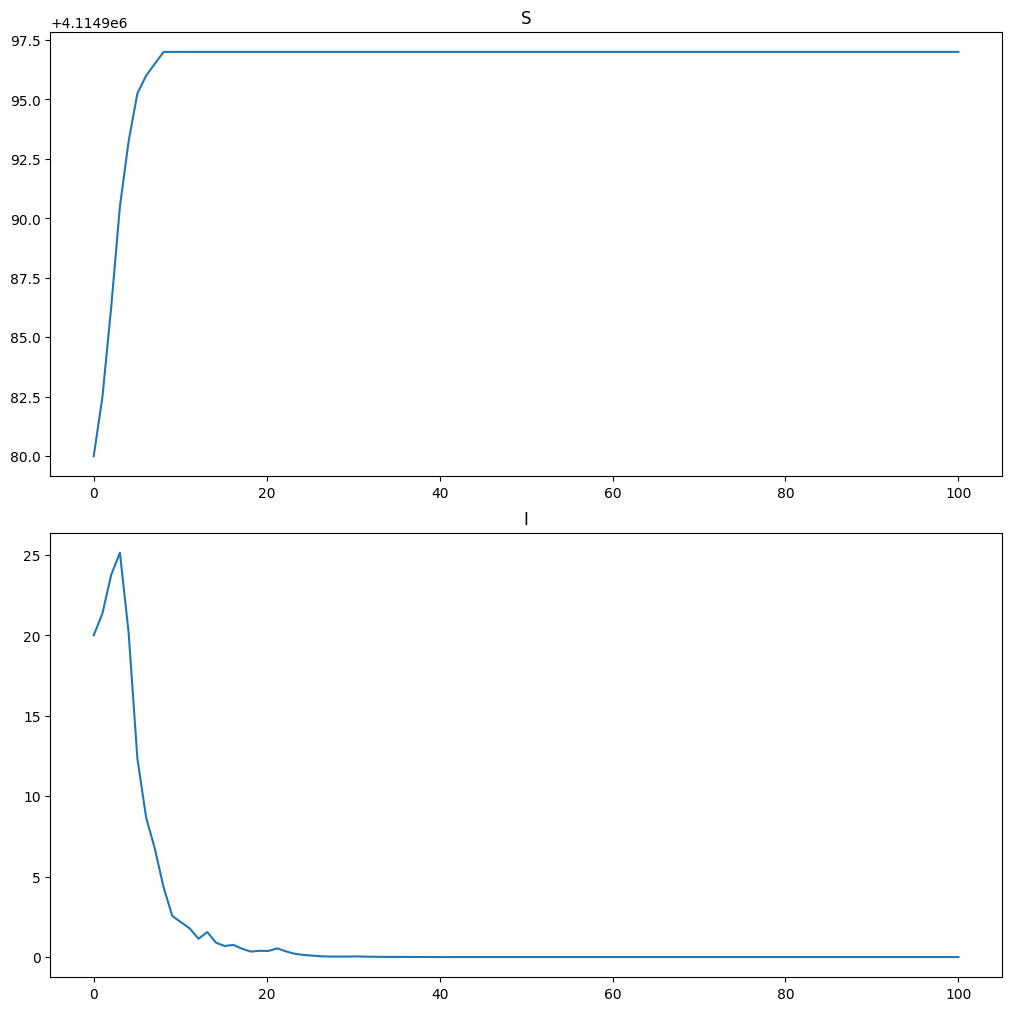

In [11]:
import diffrax
import jax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import numpy as np

sim_times = np.linspace(initial_time, final_time, 100)
dt = (final_time - initial_time) / 1000
dr_term = diffrax.ODETerm(lambda t, y, p: jnp.array(drift_term(t, y, p)))
br_term = diffrax.VirtualBrownianTree(t0=initial_time, t1=final_time, tol=dt / 10, shape=(), key=jax.random.PRNGKey(0))
di_term = diffrax.ControlTerm(lambda t, y, p: jnp.array(diffusion_term(t, y, p)), br_term)
sde_terms = diffrax.MultiTerm(dr_term, di_term)
solver = diffrax.Euler()
solution = diffrax.diffeqsolve(
    sde_terms,
    solver,
    t0=initial_time,
    t1=final_time,
    dt0=dt,
    y0=jnp.asarray([initial_values[n] for n in variable_names]),
    args=jnp.asarray([parameter_values[n] for n in parameter_names]),
    saveat=diffrax.SaveAt(ts=jnp.asarray(sim_times)),
    max_steps=None,
    throw=True
).ys

fig, axs = plt.subplots(len(variable_names), 1, figsize=(10, 5 * len(variable_names)), layout="constrained")
for i, name in enumerate(variable_names):
    axs[i].plot(sim_times, solution[:, i])
    axs[i].set_title(name)

In [12]:
print('Sucessfully defined the SDE model and generated a test simulation plot.')

Sucessfully defined the SDE model and generated a test simulation plot.
